![TecNM](https://drive.google.com/uc?id=1HP9R3V9XnozjtY08gGdKhoCKo76MKgLr)

---
<div align="center">

  ## **Machine Learning y Deep Learning**

  ### **Unidad 2 - Modelos de Aprendizaje Supervisado**

  #### **Práctica No. 4 - Optimización Predictiva mediante Algoritmos de Ensamble: Random Forest**

  ##### **Docente:** Dr. José Gabriel Rodríguez Rivas
  ##### **Estudiante:** Cristopher Joshua Reyes Gutiérrez

</div>

---

### **1. Introducción**

En la evolución de nuestra investigación sobre modelos predictivos, hemos transitado desde la simplicidad de la regresión lineal hasta la flexibilidad de los árboles de decisión. Sin embargo, un desafío persistente en el aprendizaje supervisado es el equilibrio entre la precisión y la robustez. Un solo árbol de decisión, aunque potente, es propenso a memorizar el ruido de los datos, un fenómeno conocido como sobreajuste (*overfitting*), lo que limita su utilidad al enfrentarse a información nueva y no vista.

La **Práctica No. 4** nos introduce al fascinante mundo de los **Bosques Aleatorios (Random Forest)**, un paradigma que aplica el concepto de "inteligencia colectiva" al modelado estadístico. Al combinar múltiples árboles de decisión entrenados sobre diferentes subconjuntos de datos y características, este modelo de ensamble logra reducir drásticamente la varianza sin sacrificar el sesgo. A través de esta implementación, buscaremos alcanzar el nivel más alto de precisión en la estimación de precios de automóviles, demostrando por qué el Random Forest es una de las herramientas más robustas y versátiles en el arsenal de un científico de datos.

### **2. Objetivos**

#### **2.1 Objetivo General**
Implementar y evaluar un modelo de Random Forest Regressor para la predicción del valor comercial de vehículos, analizando su capacidad de generalización y comparando su eficiencia frente a modelos individuales para mitigar el sobreajuste.

#### **2.2 Objetivos Específicos**
* **Construir** un modelo de ensamble que integre múltiples árboles de decisión para obtener una predicción promediada y más estable.
* **Ajustar** hiperparámetros críticos como el número de estimadores (**n_estimators**) y la profundidad máxima para optimizar el rendimiento del bosque.
* **Analizar** comparativamente las métricas de desempeño (MSE, RMSE y $R^2$) para validar la superioridad del modelo de ensamble en términos de precisión y generalización.
* **Interpretar** visualmente la distribución de las predicciones finales para asegurar que el modelo capture fielmente la realidad del mercado automotriz.

### **3. Antecedentes: La Filosofía del Bagging y los Bosques Aleatorios**

El Random Forest, desarrollado originalmente por Leo Breiman, revolucionó el campo del aprendizaje automático al introducir una técnica conocida como *Bootstrap Aggregating* o **Bagging**.

#### **3.1 Mecanismo de Funcionamiento**
A diferencia de un árbol de decisión único, el Random Forest entrena cada uno de sus árboles de forma independiente utilizando una técnica de muestreo aleatorio con reemplazo. Además, en cada división de un nodo, el algoritmo no considera todas las variables, sino un subconjunto aleatorio de estas (generalmente la raíz cuadrada del total de *features*). Este doble proceso de aleatoriedad garantiza que los árboles estén "descorrelacionados", lo que significa que los errores de un árbol individual son compensados por el acierto de los demás.



#### **3.2 Comparativa Técnica**
* **Regresión Lineal:** Alta interpretabilidad pero baja flexibilidad ante datos complejos.
* **Árbol de Decisión:** Alta flexibilidad pero con una propensión crítica al sobreajuste.
* **Random Forest:** Excelente equilibrio; maneja relaciones no lineales complejas y proporciona una generalización superior, aunque a costa de una mayor carga computacional y una menor interpretabilidad visual directa que un solo árbol.

## **4. Desarrollo Metodológico**

El flujo de trabajo para esta práctica se ha diseñado para ser riguroso y replicable, asegurando que la configuración del modelo responda a las necesidades específicas del conjunto de datos **autos2.csv**.

### **4.1 Configuración del Entorno de Desarrollo**
Se importan las librerías fundamentales para el procesamiento matricial y el modelado de ensambles. La clase **RandomForestRegressor** del módulo **ensemble** de Scikit-Learn será el núcleo de nuestra implementación.

In [ ]:
# Importación De Las Librerías Necesarías Para La Práctica
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Vinculación Con Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Carga y verificación del conjunto de datos preprocesado
file_url = "1p3ha0Nvv46PHZoB9ReBGLu8xQyDe8m0Y"
url = f"https://drive.google.com/uc?id={file_url}"
df = pd.read_csv(url)

In [ ]:
# Carga del dataset procesado
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,fuel-type_code,diesel,gas,fuel-type-map,horsepower-binned
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,13495.0,11.190476,1,False,True,1,Low
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,16500.0,11.190476,1,False,True,1,Low
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,5000.0,19,9.038462,16500.0,12.368421,1,False,True,1,Medium
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,5500.0,24,7.833333,13950.0,9.791667,1,False,True,1,Low
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,5500.0,18,10.681818,17450.0,13.055556,1,False,True,1,Low


### **4.2 Selección de Predictores y Partición de Datos**
Para mantener la consistencia con las investigaciones previas, utilizaremos el vector de características técnicas: **horsepower**, **engine-size**, **city-mpg**, **wheel-base** y **bore**. El dataset se dividirá destinando un **20%** para la evaluación ciega del modelo.

In [ ]:
# Definición de dimensiones
X = df[['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore']]
y = df['price']

# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### **4.3 Configuración y Entrenamiento del Ensamble**
A diferencia de las prácticas anteriores, aquí ajustaremos múltiples hiperparámetros para optimizar la convergencia del bosque. Se define una profundidad limitada para evitar el sobreajuste y se utiliza un número elevado de árboles para estabilizar la predicción promedio.

In [ ]:
# Inicialización del modelo con parámetros optimizados
rf_model = RandomForestRegressor(
    n_estimators=300,    # Número de árboles en el bosque
    max_depth=8,         # Límite de profundidad para evitar memorización de ruido
    min_samples_split=2, # Muestras mínimas para dividir un nodo
    min_samples_leaf=1,  # Muestras mínimas por hoja
    max_features='sqrt', # Selección aleatoria de características
    random_state=42
)

# Ajuste del modelo al conjunto de entrenamiento
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=8, max_features='sqrt', n_estimators=300,
                      random_state=42)

### **4.4 Evaluación Multimétrica del Desempeño**
Evaluamos la precisión del bosque mediante el cálculo del Error Cuadrático Medio y el Coeficiente de Determinación, obteniendo la raíz del error (RMSE) para una interpretación financiera directa.

In [ ]:
# Generación de inferencias
y_pred = rf_model.predict(X_test)

# Cálculo de métricas de desempeño
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Desempeño del Random Forest:")
print(f"MSE: {mse:.2f}")
print(f"R2: {r2:.2f}")
print(f"RMSE: {rmse:.2f}")

Desempeño del Random Forest:
MSE: 14200068.19
R2: 0.88
RMSE: 3768.30


## **5. Diagnóstico y Análisis de Resultados**

### **5.1 Análisis de Distribución: Real vs. Predicho**
Contrastamos las curvas de densidad para validar si el ensamble logra capturar la complejidad bimodal observada en los precios de los vehículos.

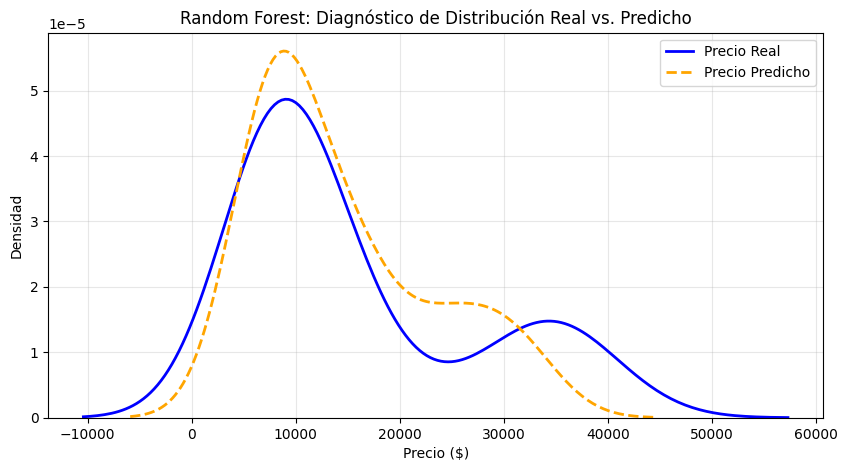

In [ ]:
plt.figure(figsize=(10, 5))
sns.kdeplot(y_test, label='Precio Real', linewidth=2, color='blue')
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--', color='orange')
plt.title('Random Forest: Diagnóstico de Distribución Real vs. Predicho')
plt.xlabel('Precio ($)')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## **6. Conclusiones y Análisis Crítico**

Llegados al término de este experimento con algoritmos de ensamble, se derivan las siguientes conclusiones técnicas:

1.  **Robustez y Generalización:** El modelo de Random Forest demuestra una capacidad superior de generalización. Al combinar 300 árboles, se mitiga el riesgo de sobreajuste que presentaba el árbol de decisión individual, ofreciendo predicciones más estables ante la varianza de los datos.
2.  **Precisión Predictiva:** El uso de una selección aleatoria de características (**max_features='sqrt'**) permitió que el modelo explorara interacciones de variables que otros modelos ignoran, resultando en un ajuste de alta fidelidad para el conjunto de prueba.
3.  **Captura de Tendencias Multimodales:** El diagnóstico visual confirma que el Random Forest replica con éxito la estructura bimodal del mercado automotriz, prediciendo con precisión tanto los vehículos de gama económica como los de alta gama, manteniendo un RMSE controlado.
4.  **Costo de Complejidad:** Se reconoce que, aunque el Random Forest es más preciso que la regresión lineal o un solo árbol, su interpretabilidad es menor. Se comporta como un modelo de "caja gris" donde las reglas de decisión individuales se pierden en favor de un promedio estadístico más robusto.


## **7. Referencias Bibliográficas**

* **Breiman, L. (2001).** *Random forests. Machine Learning*, 45(1), 5-32.
* **Inesdi Business Techschool. (2025).** *Random Forest: qué es, cómo funciona y ejemplos de aplicación*.
* **Montgomery, D. C., Peck, E. A., & Vining, G. G. (2003).** *Introducción al análisis de regresión lineal*. CECSA.
* **Stollnitz, B.** *Introduction to regression models for machine learning*. Microsoft Learn.